<a href="https://colab.research.google.com/github/MelB18/Quanten/blob/main/H2_VQE_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Um zu verstehen, wie ein Quantencomputer chemische Berechnungen anstellt, betrachten wir das einfachste aller Moleküle: molekularen Wasserstoff H2.

An diesem System lässt sich der fundamentale Unterschied zwischen klassischer und Quantenberechnung exakt zeigen.

Ein H2-Molekül besteht aus:
* 2 Atomkernen (Protonen)
* 2 Elektronen, die sich in bestimmten räumlichen Bereichen bewegen (Orbitalen).

Das Ziel des VQE-Algorithmus ist es, den optimalen Abstand zwischen den beiden Kernen zu finden, bei dem das Molekül am stabilsten ist (die niedrigste Energie besitzt).

In der einfachsten quantenmechanischen Beschreibung hat jedes Wasserstoffatom ein Orbital. Wenn sie sich verbinden, entstehen daraus zwei Molekülorbitale (ein bindendes und ein antibindendes).

Da jedes Orbital Platz für zwei Elektronen (Spin up und Spin down) bietet, gibt es insgesamt 4 mögliche Zustände (Molekülorbitale), auf die sich unsere 2 Elektronen verteilen können.


Wir nutzen genau 4 Qubits, um diese 4 Zustände im Quantencomputer abzubilden:

* Qubit 0: Bindendes Orbital - Spin up
* Qubit 1: Bindendes Orbital - Spin down
* Qubit 2: Antibindendes Orbital - Spin up
* Qubit 3: Antibindendes Orbital - Spin down

Ein Qubit im Zustand |1⟩  bedeutet „besetzt“, im Zustand |0⟩ bedeutet es „leer“. Der energetische Grundzustand von Wasserstoff (beide Elektronen im stabilen, bindenden Orbital) sieht als Qubit-Register so aus: |1100⟩


Ein Quantencomputer versetzt die Qubits in eine Überlagerung (Superposition) aus verschiedenen Zuständen:

ψ(θ) = ( α |1100⟩ + β |0011⟩ )


Der Parameter (θ) (Theta) steuert dabei das Verhältnis Alpha und Beta der Zustände zueinander. Er repräsentiert physikalisch den Abstand der Atomkerne.

Der VQE-Algorithmus läuft nun in einer iterativen Schleife ab:

Der Quantencomputer stellt den Zustand für einen bestimmten Wert von Theta ein und misst die Energie des Systems. Durch die Quantenüberlagerung misst er die Wechselwirkungen der Elektronen instantan.

Der Klassischer Computer liest den gemessenen Energiewert aus. Wenn die Energie noch nicht minimal ist, nutzt sie ein mathematisches Optimierungsverfahren (z. B. das Gradientenverfahren) und berechnet ein neues, leicht verändertes Theta.

Wenn man diesen Prozess für verschiedene Kernabstände wiederholt, erhält man eine Energiekurve:

* Zu nah zusammen: Die positiv geladenen Kerne stoßen sich extrem stark ab. Die Energie schießt nach oben.

* Das Minimum (Der „Sweet Spot“): Bei genau 0,74 Ångström erreicht die Kurve ihren tiefsten Punkt. Hier heben sich die Abstoßung der Kerne und die Anziehung durch die Elektronen perfekt auf. Das ist die reale Bindungslänge von Wasserstoff.


* Zu weit auseinander: Die Energie flacht ab. Das Molekül dissoziiert, die Atome spüren sich nicht mehr.



Hier ist ein einfaches, praxisnahes Python-Beispiel mit Qiskit (unter Nutzung moderner Pakete wie qiskit-nature), das zeigt, wie man die Grundzustandsenergie des Wasserstoff-Moleküls (H₂) mithilfe des VQE-Algorithmus (Variational Quantum Eigensolver) berechnet.Der Code ist so aufgebaut, dass er die Molekülgeometrie definiert, die Elektronenorbitale auf Qubits abbildet und die VQE-Schleife startet.

In [ ]:
%pip install qiskit qiskit_nature

ERROR: Could not find a version that satisfies the requirement qisik_ibm_runtime (from versions: none)
ERROR: No matching distribution found for qisik_ibm_runtime


In [ ]:

# Install required packages.
%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found ex

In [ ]:
%pip install qiskit-nature

https://pyscf.org/user/index.html

In [ ]:
%pip install pyscf

In [ ]:
%pip install pyscf qiskit-nature-pyscf


In [ ]:
import pyscf
from qiskit_nature.second_q.drivers import PySCFDriver
print("Erfolgreich geladen!")


Erfolgreich geladen!


In [ ]:
from pyscf import gto, scf

# 1. Molekül definieren und das Basisset zuweisen
mol = gto.M(
    atom='O 0 0 0; H 0 0.757 0.587; H 0 -0.757 0.587',
    basis='sto-3g'  # Hier wird STO-3G direkt als Text übergeben
    )

# 2. Hartree-Fock Berechnung ausführen
mf = scf.RHF(mol)
mf.kernel()


converged SCF energy = -74.9630631297276


np.float64(-74.96306312972764)

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver

# 1. Driver für das Wasserstoff-Molekül definieren
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735", basis="sto3g")

# 2. Berechnung starten
problem = driver.run()

# 3. Ergebnis überprüfen (Gibt die klassische Hartree-Fock-Referenzenergie aus)
print(f"Hartree-Fock Energie: {problem.reference_energy:.6f} Hartree")
print(f"Anzahl der Elektronen: {problem.num_particles}")
print(f"Anzahl der Molekülorbitale: {problem.num_spatial_orbitals}")


Hartree-Fock Energie: -1.116999 Hartree
Anzahl der Elektronen: (1, 1)
Anzahl der Molekülorbitale: 2


In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

# 1. Driver definieren (Molekül-Geometrie und Basisset)
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",  # H2-Molekül mit Bindungslänge
    basis="sto3g"                  # Minimales Basisset
    )

# 2. PySCF im Hintergrund ausführen
# Erzeugt ein "ElectronicStructureProblem"
problem = driver.run()

# 3. Elektronischen Hamiltonian (in zweiter Quantisierung) abrufen
hamiltonian = problem.hamiltonian
second_q_op = hamiltonian.second_q_op()

print("--- Operator in zweiter Quantisierung (Fermionisch) ---")
print(second_q_op)

# 4. In Qubit-Operatoren transformieren (für den Quantencomputer)
mapper = JordanWignerMapper()
qubit_op = mapper.map(second_q_op)

print("\n--- Qubit-Hamiltonian (Pauli-Strings) ---")
print(qubit_op)


--- Operator in zweiter Quantisierung (Fermionisch) ---
Fermionic Operator
number spin orbitals=4, number terms=36
  0.33785507740175813 * ( +_0 +_0 -_0 -_0 )
+ 0.33229086512764816 * ( +_0 +_1 -_1 -_0 )
+ 0.33785507740175813 * ( +_0 +_2 -_2 -_0 )
+ 0.33229086512764816 * ( +_0 +_3 -_3 -_0 )
+ 0.0904655998921157 * ( +_0 +_0 -_1 -_1 )
+ 0.0904655998921157 * ( +_0 +_1 -_0 -_1 )
+ 0.0904655998921157 * ( +_0 +_2 -_3 -_1 )
+ 0.0904655998921157 * ( +_0 +_3 -_2 -_1 )
+ 0.0904655998921157 * ( +_1 +_0 -_1 -_0 )
+ 0.0904655998921157 * ( +_1 +_1 -_0 -_0 )
+ 0.0904655998921157 * ( +_1 +_2 -_3 -_0 )
+ 0.0904655998921157 * ( +_1 +_3 -_2 -_0 )
+ 0.33229086512764816 * ( +_1 +_0 -_0 -_1 )
+ 0.34928686136600906 * ( +_1 +_1 -_1 -_1 )
+ 0.33229086512764816 * ( +_1 +_2 -_2 -_1 )
+ 0.34928686136600906 * ( +_1 +_3 -_3 -_1 )
+ 0.33785507740175813 * ( +_2 +_0 -_0 -_2 )
+ 0.33229086512764816 * ( +_2 +_1 -_1 -_2 )
+ 0.33785507740175813 * ( +_2 +_2 -_2 -_2 )
+ 0.33229086512764816 * ( +_2 +_3 -_3 -_2 )
+ 0.090465599

i = 0.7300
Berechneter Energie-Erwartungswert: -0.951764 Hartree
i = 0.7305


/tmp/ipykernel_14017/3587845999.py:26: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  circuit = RealAmplitudes(num_qubits=num_qubits, reps=1)


Berechneter Energie-Erwartungswert: -0.382988 Hartree
i = 0.7311
Berechneter Energie-Erwartungswert: -0.296695 Hartree
i = 0.7316
Berechneter Energie-Erwartungswert: -0.823166 Hartree
i = 0.7321
Berechneter Energie-Erwartungswert: -0.424167 Hartree
i = 0.7326
Berechneter Energie-Erwartungswert: -0.203957 Hartree
i = 0.7332
Berechneter Energie-Erwartungswert: -0.855521 Hartree
i = 0.7337
Berechneter Energie-Erwartungswert: -0.549223 Hartree
i = 0.7342
Berechneter Energie-Erwartungswert: -0.411288 Hartree
i = 0.7347
Berechneter Energie-Erwartungswert: -0.256700 Hartree
i = 0.7353
Berechneter Energie-Erwartungswert: -0.780698 Hartree
i = 0.7358
Berechneter Energie-Erwartungswert: -0.955722 Hartree
i = 0.7363
Berechneter Energie-Erwartungswert: -0.492120 Hartree
i = 0.7368
Berechneter Energie-Erwartungswert: -0.544936 Hartree
i = 0.7374
Berechneter Energie-Erwartungswert: -0.451298 Hartree
i = 0.7379
Berechneter Energie-Erwartungswert: -0.718014 Hartree
i = 0.7384
Berechneter Energie-Erwar

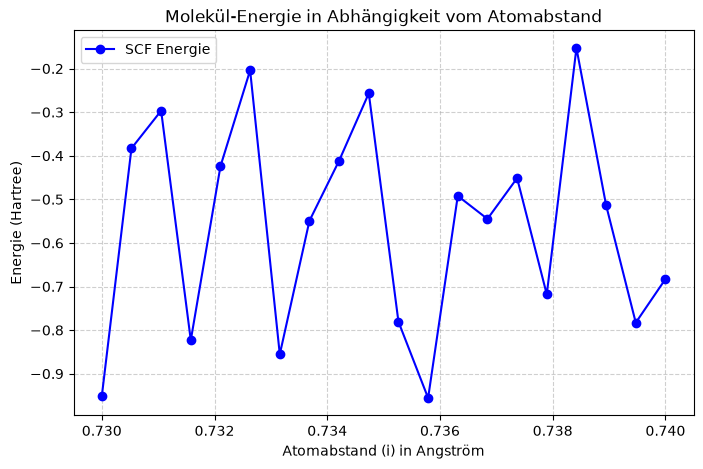

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import StatevectorEstimator  # Lokaler V2 Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

# 1. Leere Listen erstellen, um die Daten zu sammeln
abstaende = []
energien = []

# Start, Ende (inklusive), Anzahl der Schritte
for i in np.linspace(0.73, 0.74, 20):
  print(f"i = {i:.4f}")

  # 1. Driver & Operatoren wie gewohnt vorbereiten 0.735
  driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 {i}", basis="sto3g")
  problem = driver.run()
  secondq_op = problem.hamiltonian.second_q_op()

  mapper = JordanWignerMapper()
  qubit_op = mapper.map(second_q_op)  # Dies ist unser Observable

  # 2. Parametrisierten Quantenschaltkreis (Ansatz) erstellen
  num_qubits = qubit_op.num_qubits
  circuit = RealAmplitudes(num_qubits=num_qubits, reps=1)

  # 3. Den V2 Estimator initialisieren
  estimator = StatevectorEstimator()

  # 4. Parameter-Werte definieren (Zufällige Startwerte für die Rotation)
  parameter_values = np.random.uniform(0, np.pi, circuit.num_parameters)

  # 5. Ein "PUB" definieren: (Circuit, Observables, ParameterValues)
  pub = (circuit, qubit_op, parameter_values)

  # 6. Job ausführen und Ergebnis abrufen
  job = estimator.run([pub])
  result = job.result()

  # 7. Erwartungswert (Energie) ausgeben
  # In V2 greift man über den Index der übergebenen PUBs auf Daten zu
  pub_result = result[0]
  expectation_value = pub_result.data.evs

  # Werte an die Listen anhängen
  abstaende.append(i)
  energien.append(expectation_value)

  #print(f"Anzahl der Qubits: {num_qubits}")
  print(f"Berechneter Energie-Erwartungswert: {expectation_value:.6f} Hartree")


# 3. Visualisierung mit Matplotlib erstellen
plt.figure(figsize=(8, 5))

# Linie und Datenpunkte zeichnen
plt.plot(abstaende, energien, marker='o', linestyle='-', color='b', label='SCF Energie')

# Diagramm beschriften
plt.title('Molekül-Energie in Abhängigkeit vom Atomabstand')
plt.xlabel('Atomabstand (i) in Angström')
plt.ylabel('Energie (Hartree)')
plt.grid(True, linestyle='--', alpha=0.6) # Fügt ein Gitternetz hinzu
plt.legend()

# Diagramm in Colab anzeigen
plt.show()

PySCFDriver: Ein klassischer Chemie-Solver berechnet im Hintergrund die Integrale für die Atomorbitale. Das ist der vorgeschaltete klassische Schritt, um das System für den Quantenrechner handhabbar zu machen.

JordanWignerMapper: Dieser Algorithmus sorgt dafür, dass die physikalischen Eigenschaften von Elektronen (wie das Pauli-Prinzip, dass keine zwei Elektronen den exakt gleichen Zustand besetzen dürfen) mathematisch sauber auf die Zustände der Qubits übertragen werden.



